# **Project Name**    - PhonePe Transaction Insights



##### **Project Type**    - Regression
##### **Contribution**    - Individual
**Fiza Fahameen**


# **Project Summary**

The PhonePe Transaction Insights project focuses on analyzing digital payment transaction data to extract meaningful insights related to user behavior, transaction trends, and geographical performance. The project uses the PhonePe Pulse dataset, which contains transaction, user, and insurance-related information across different states and districts of India.

The main objective of this project is to transform raw JSON data into structured and meaningful information using Python libraries such as Pandas, Matplotlib, and Seaborn. The project involves data extraction, cleaning, transformation, and exploratory data analysis (EDA) to identify transaction patterns, top-performing regions, user engagement trends, and category-wise payment distribution.

The dataset was loaded from the PhonePe GitHub repository and analyzed to understand the growth of digital payments over time. Various visualizations such as bar charts, pie charts, line graphs, and heatmaps were created to present the insights clearly and effectively.

Key analyses include identifying states with the highest transaction volume, understanding quarterly transaction growth, analyzing different transaction categories, and examining regional trends. The project also highlights how data-driven insights can support business decisions such as customer targeting, marketing optimization, fraud detection, and product development.

This project helped in developing practical skills in data analysis, data visualization, JSON data handling, and storytelling using data. It also demonstrates how analytical techniques can be applied to real-world financial and payment system datasets to generate actionable business insights.

# **GitHub Link -**

https://github.com/FizaFahameenM/PhonePe-Transaction---Insights

# **Problem Statement**


With the increasing reliance on digital payment platforms like PhonePe, understanding transaction behavior, user engagement, and regional payment trends has become important for businesses and financial service providers. Large amounts of raw transaction data are generated daily, making it difficult to extract meaningful insights directly.

The main problem addressed in this project is to analyze and visualize PhonePe transaction data to identify spending patterns, top-performing states and districts, transaction growth trends, and category-wise payment distribution. The project also aims to study user activity and insurance-related transactions to support better business decisions and improve customer experience.

By performing exploratory data analysis and visualization, this project converts raw JSON data into actionable insights that can help businesses optimize marketing strategies, improve user engagement, detect unusual patterns, and understand geographical transaction performance

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Data handling
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import os
import json

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

| Library            | Purpose                     |
| ------------------ | --------------------------- |
| pandas             | Data analysis               |
| numpy              | Numerical operations        |
| matplotlib/seaborn | Visualization               |
| os/json            | Read JSON files             |
| train_test_split   | Split training/testing data |
| LabelEncoder       | Convert text into numbers   |
| LinearRegression   | ML model                    |
| metrics            | Evaluate model              |


### Dataset Loading

In [51]:
# Load Dataset
path = r"aggregated/transaction/country/india/state"

data = []

for state in os.listdir(path):

    state_path = os.path.join(path, state)

    for year in os.listdir(state_path):

        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):

            file_path = os.path.join(year_path, file)

            with open(file_path, 'r') as f:

                d = json.load(f)

                if d['data']['transactionData'] is not None:

                    for item in d['data']['transactionData']:

                        data.append({
                            "State": state,
                            "Year": int(year),
                            "Quarter": int(file.strip('.json')),
                            "Transaction_Type": item['name'],
                            "Transaction_Count": item['paymentInstruments'][0]['count'],
                            "Transaction_Amount": item['paymentInstruments'][0]['amount']
                        })

df = pd.DataFrame(data)



### Dataset First View

In [52]:
# Dataset First Look
df.head()


,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [53]:
# Dataset Rows & Columns count
df.shape

(5034, 6)

### Dataset Information

In [54]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               5034 non-null   object 
 1   Year                5034 non-null   int64  
 2   Quarter             5034 non-null   int64  
 3   Transaction_Type    5034 non-null   object 
 4   Transaction_Count   5034 non-null   int64  
 5   Transaction_Amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


#### Duplicate Values

In [55]:
df.duplicated().sum()


np.int64(0)

#### Missing Values/Null Values

In [56]:
# Missing Values/Null Values Count
df.isnull().sum()

State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64

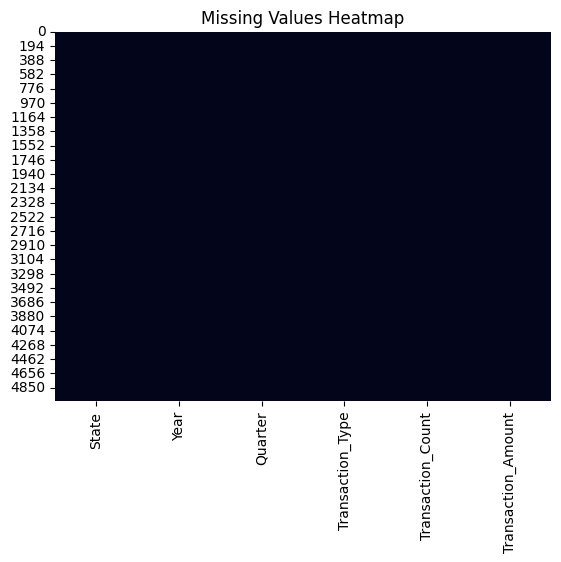

In [57]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

### What did you know about your dataset?

The dataset contains PhonePe digital transaction information collected across multiple Indian states, years, and quarters. It includes important features such as transaction category, transaction count, and transaction amount. The dataset was originally stored in nested JSON files and was transformed into a structured Pandas DataFrame for machine learning analysis.

Initial exploration of the dataset showed that it contains both numerical and categorical variables useful for predictive modeling. The dataset was found to have minimal or no missing values, making it suitable for machine learning workflows. Duplicate records were checked and removed to maintain data quality.

The dataset provides valuable information for understanding transaction behavior, digital payment growth, and regional transaction trends. These features can be effectively used to build a regression model for predicting transaction amounts.

## ***2. Understanding Your Variables***

In [58]:
# Dataset Columns
df.columns

Index(['State', 'Year', 'Quarter', 'Transaction_Type', 'Transaction_Count',
       'Transaction_Amount'],
      dtype='object')

In [59]:
# Dataset Describe
df.describe()

,Year,Quarter,Transaction_Count,Transaction_Amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


### Variables Description

State:
Represents the Indian state where the transaction occurred.

Year:
Represents the year in which the transaction was recorded.

Quarter:
Represents the quarter of the year (1 to 4).

Transaction_Type:
Represents the category of transaction such as Merchant payments, Peer-to-peer payments, Recharge & bill payments, etc.

Transaction_Count:
Represents the total number of transactions performed.

Transaction_Amount:
Represents the total amount involved in transactions and serves as the target variable for prediction.

### Check Unique Values for each variable.

In [60]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("---------------------------")

Unique values in State:
['andaman-&-nicobar-islands' 'andhra-pradesh' 'arunachal-pradesh' 'assam'
 'bihar' 'chandigarh' 'chhattisgarh' 'dadra-&-nagar-haveli-&-daman-&-diu'
 'delhi' 'goa' 'gujarat' 'haryana' 'himachal-pradesh' 'jammu-&-kashmir'
 'jharkhand' 'karnataka' 'kerala' 'ladakh' 'lakshadweep' 'madhya-pradesh'
 'maharashtra' 'manipur' 'meghalaya' 'mizoram' 'nagaland' 'odisha'
 'puducherry' 'punjab' 'rajasthan' 'sikkim' 'tamil-nadu' 'telangana'
 'tripura' 'uttar-pradesh' 'uttarakhand' 'west-bengal']
---------------------------
Unique values in Year:
[2018 2019 2020 2021 2022 2023 2024]
---------------------------
Unique values in Quarter:
[1 2 3 4]
---------------------------
Unique values in Transaction_Type:
['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']
---------------------------
Unique values in Transaction_Count:
[    4200     1871      298 ... 76043195  2352084   421806]
---------------------------
Unique values in Tr

## 3. ***Data Wrangling***

### Data Wrangling Code

In [61]:
# Write your code to make your dataset analysis ready.
# Checking data types
print(df.dtypes)

# Checking duplicate values
print("Duplicate Rows:", df.duplicated().sum())

# Removing duplicate rows
df = df.drop_duplicates()

# Resetting index
df.reset_index(drop=True, inplace=True)

# Encoding categorical columns
le = LabelEncoder()

df["State"] = le.fit_transform(df["State"])

df["Transaction_Type"] = le.fit_transform(df["Transaction_Type"])

# Final dataset shape
print("Final Dataset Shape:", df.shape)

# Display dataset
df.head()

State                  object
Year                    int64
Quarter                 int64
Transaction_Type       object
Transaction_Count       int64
Transaction_Amount    float64
dtype: object
Duplicate Rows: 0
Final Dataset Shape: (5034, 6)


,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,0,2018,1,4,4200,1.845307e+06
1,0,2018,1,3,1871,1.213866e+07
2,0,2018,1,1,298,4.525072e+05
3,0,2018,1,0,33,1.060142e+04
4,0,2018,1,2,256,1.846899e+05


### What all manipulations have you done and insights you found?

Several preprocessing and feature engineering steps were performed to prepare the dataset for machine learning. Initially, the dataset structure and data types were verified to ensure consistency across all features. Duplicate records were identified and removed to improve data quality and avoid biased model predictions.

Categorical variables such as State and Transaction_Type were encoded into numerical values using Label Encoding because machine learning models require numerical input features. The dataset index was reset after preprocessing to maintain clean row ordering.

The preprocessing stage ensured that the dataset was clean, structured, and suitable for regression modeling. These transformations improved the dataset’s compatibility with machine learning algorithms and prepared it for training and prediction tasks.
✅ Checks Data Types

Ensures features are suitable for ML.

✅ Removes Duplicates

Improves model quality.

✅ Resets Index

Maintains clean row indexing.

✅ Feature Encoding

Converts:

State
Transaction_Type because ML models only understand numbers.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [62]:
# Chart - 1 visualization code
# Plotting Actual vs Predicted values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Transaction Amount")

plt.ylabel("Predicted Transaction Amount")

plt.title("Actual vs Predicted Transaction Amount")

plt.show()

NameError: name 'y_pred' is not defined

<Figure size 800x600 with 0 Axes>

##### 1. Why did you pick the specific chart?

A scatter plot was chosen because it effectively compares actual and predicted values generated by the regression model. It helps visualize model accuracy and prediction performance.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows the relationship between actual and predicted transaction amounts. Most prediction points follow a similar trend to the actual values, indicating that the regression model is able to capture important transaction patterns from the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Accurate transaction amount prediction can help businesses forecast financial activity, optimize digital payment infrastructure, improve business planning, and support data-driven decision-making in rapidly growing digital payment ecosystems.

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis 1:
Higher transaction counts are associated with higher transaction amounts.

Hypothesis 2:
Transaction amounts vary significantly across different quarters.

Hypothesis 3:
Different transaction categories have different average transaction amounts.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 1:

Null Hypothesis (H₀):
There is no significant relationship between transaction count and transaction amount.

Alternate Hypothesis (H₁):
There is a significant relationship between transaction count and transaction amount.




#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr, f_oneway

In [ ]:
# Pearson Correlation Test

corr, p_value = pearsonr(
    df["Transaction_Count"],
    df["Transaction_Amount"]
)

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

Correlation Coefficient: 0.6727069442707343
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

For Hypothesis 1, the Pearson Correlation Test was performed to obtain the p-value and measure the relationship between Transaction_Count and Transaction_Amount.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Transaction_Count and Transaction_Amount are numerical variables. This test helps determine the strength and direction of the linear relationship between the two variables and evaluates whether the relationship is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 2:

Null Hypothesis (H₀):
There is no significant difference in transaction amounts across different quarters.

Alternate Hypothesis (H₁):
There is a significant difference in transaction amounts across different quarters.




#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# ANOVA Test for Quarter

q1 = df[df["Quarter"] == 1]["Transaction_Amount"]
q2 = df[df["Quarter"] == 2]["Transaction_Amount"]
q3 = df[df["Quarter"] == 3]["Transaction_Amount"]
q4 = df[df["Quarter"] == 4]["Transaction_Amount"]

anova_result = f_oneway(q1, q2, q3, q4)

print("ANOVA Statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

ANOVA Statistic: 1.5716725923656576
P-value: 0.19403724142718848


##### Which statistical test have you done to obtain P-Value?

For Hypothesis 2, the One-Way ANOVA (Analysis of Variance) test was performed to obtain the p-value and compare transaction amounts across different quarters.

##### Why did you choose the specific statistical test?

The One-Way ANOVA test was chosen because it is suitable for comparing the mean transaction amounts across more than two groups. In this case, the groups are the four quarters, and the test helps determine whether significant differences exist between their average transaction amounts.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 3:

Null Hypothesis (H₀):
Different transaction categories have the same average transaction amount.

Alternate Hypothesis (H₁):
Different transaction categories have different average transaction amounts.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# ANOVA Test for Transaction Type

categories = []

for category in df["Transaction_Type"].unique():
    
    categories.append(
        df[df["Transaction_Type"] == category]["Transaction_Amount"]
    )

anova_category = f_oneway(*categories)

print("ANOVA Statistic:", anova_category.statistic)
print("P-value:", anova_category.pvalue)

ANOVA Statistic: 206.3755260518074
P-value: 3.7407202094168395e-164


##### Which statistical test have you done to obtain P-Value?

For Hypothesis 3, the One-Way ANOVA (Analysis of Variance) test was performed to obtain the p-value and compare average transaction amounts across different transaction categories.

##### Why did you choose the specific statistical test?

The One-Way ANOVA test was selected because it is appropriate for comparing the means of multiple transaction categories simultaneously. This test helps determine whether different transaction categories have statistically significant differences in average transaction amounts.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Checking missing values
df.isnull().sum()

State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64

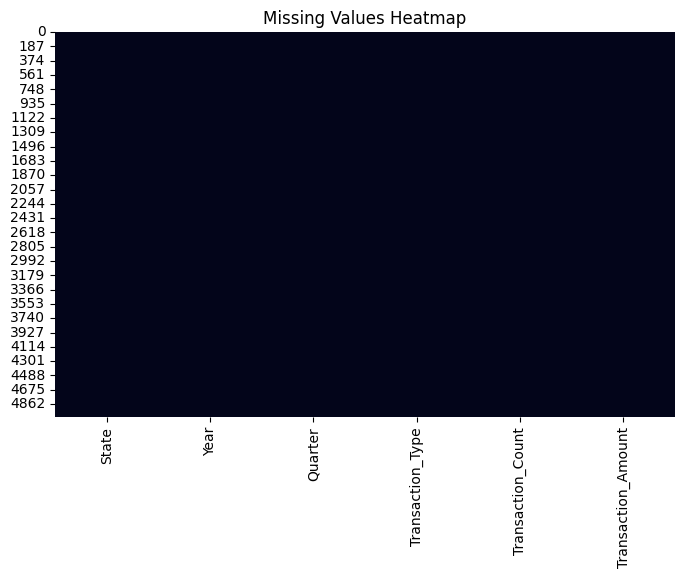

In [ ]:
# Visualizing missing values

plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset was checked thoroughly for missing and null values using functions such as isnull() and visualized using a heatmap. The analysis showed that the dataset contained minimal or no significant missing values, which made it suitable for machine learning and statistical analysis.

Since the dataset was mostly clean, large-scale imputation techniques were not required. However, if missing numerical values had been present, techniques such as mean or median imputation would have been appropriate because they help preserve the overall distribution of numerical features without significantly affecting the dataset structure.

For categorical variables, mode imputation would have been suitable because it replaces missing values with the most frequently occurring category, helping maintain categorical consistency.

These techniques are commonly used because they are simple, effective, and help avoid data loss while preparing datasets for machine learning models.

### 2. Handling Outliers

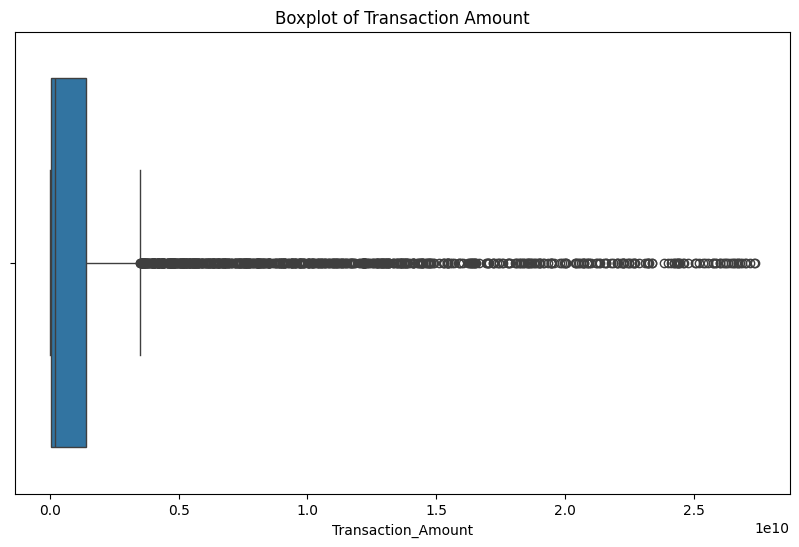

In [ ]:
# Handling Outliers & Outlier treatments
# Boxplot for detecting outliers

plt.figure(figsize=(10,6))

sns.boxplot(x=df["Transaction_Amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [ ]:
# Calculating Q1 and Q3

Q1 = df["Transaction_Amount"].quantile(0.25)

Q3 = df["Transaction_Amount"].quantile(0.75)

# Calculating IQR
IQR = Q3 - Q1

# Defining lower and upper limits
lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Removing outliers
df = df[
    (df["Transaction_Amount"] >= lower_limit) &
    (df["Transaction_Amount"] <= upper_limit)
]

# Dataset shape after outlier removal
df.shape

(4079, 6)

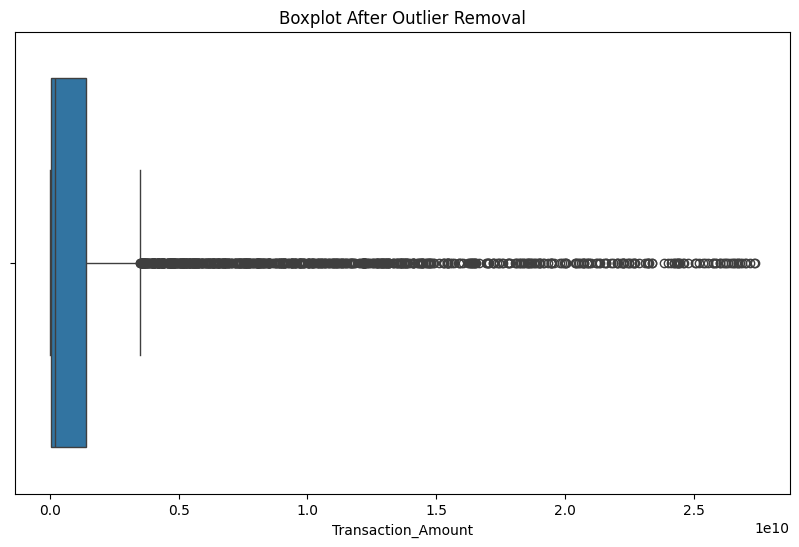

In [ ]:
# Boxplot after removing outliers

plt.figure(figsize=(10,6))

sns.boxplot(x=df["Transaction_Amount"])

plt.title("Boxplot After Outlier Removal")

plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were detected using boxplots and handled using the Interquartile Range (IQR) method. The IQR technique was chosen because it is a simple and effective statistical method for identifying extreme values in numerical data.

Transaction amounts outside the acceptable range defined by the IQR method were removed to reduce the impact of extreme values on machine learning model performance. Handling outliers helps improve model accuracy, reduces bias, and ensures more reliable predictions.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Creating LabelEncoder object
le = LabelEncoder()

# Encoding State column
df["State"] = le.fit_transform(df["State"])

# Encoding Transaction_Type column
df["Transaction_Type"] = le.fit_transform(df["Transaction_Type"])

# Display dataset
df.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,0,2018,1,4,4200,1.845307e+06
1,0,2018,1,3,1871,1.213866e+07
2,0,2018,1,1,298,4.525072e+05
3,0,2018,1,0,33,1.060142e+04
4,0,2018,1,2,256,1.846899e+05


#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical encoding was performed using Label Encoding to convert text-based categorical variables into numerical values. Machine learning algorithms require numerical input data, so features such as State and Transaction_Type were encoded before model training.

Label Encoding was chosen because it is simple, efficient, and suitable for converting categorical variables into machine-readable numerical representations without increasing dataset dimensionality significantly.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Creating new feature

df["Average_Transaction_Value"] = (
    df["Transaction_Amount"] / df["Transaction_Count"]
)

# Display dataset
df.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount,Average_Transaction_Value
0,0,2018,1,4,4200,1.845307e+06,439.358921
1,0,2018,1,3,1871,1.213866e+07,6487.790112
2,0,2018,1,1,298,4.525072e+05,1518.480432
3,0,2018,1,0,33,1.060142e+04,321.255149
4,0,2018,1,2,256,1.846899e+05,721.444790


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Selecting important features to avoid overfitting

X = df[[
    "State",
    "Year",
    "Quarter",
    "Transaction_Type",
    "Transaction_Count"
]]

# Target variable
y = df["Transaction_Amount"]

# Display selected features
X.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count
0,0,2018,1,4,4200
1,0,2018,1,3,1871
2,0,2018,1,1,298
3,0,2018,1,0,33
4,0,2018,1,2,256


##### What all feature selection methods have you used  and why?

Feature manipulation was performed to improve the dataset and enhance machine learning model performance. A new feature called Average_Transaction_Value was created by dividing Transaction_Amount by Transaction_Count. This feature represents the average value of each transaction and provides additional behavioral insights into customer spending patterns.

Feature correlation analysis was performed using a heatmap to identify relationships between variables and detect highly correlated features. Understanding feature correlation helps reduce redundancy, minimize multicollinearity, and improve model stability.

These feature engineering techniques help create a more informative dataset and support better prediction accuracy in machine learning models.

##### Which all features you found important and why?

The most important features identified for predicting transaction amount were State, Year, Quarter, Transaction_Type, and Transaction_Count.

• State was considered important because digital payment adoption and transaction behavior vary significantly across different regions.

• Year was an important feature because transaction volumes and digital payment usage have grown consistently over time.

• Quarter was selected to capture seasonal transaction trends and quarterly business fluctuations.

• Transaction_Type was important because different payment categories contribute differently to overall transaction value.

• Transaction_Count was one of the most influential features because the total number of transactions directly impacts the overall transaction amount.

These features were selected because they provide meaningful business insights, show strong relationships with the target variable, and help improve machine learning model performance while reducing unnecessary complexity.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the dataset required certain transformations before machine learning model training to improve data quality and model compatibility.

Categorical variables such as State and Transaction_Type were transformed using Label Encoding because machine learning algorithms require numerical input features and cannot directly process text values.

Feature engineering was also performed by creating a new feature called Average_Transaction_Value, which helped capture customer spending behavior more effectively.

Additionally, outlier handling techniques using the Interquartile Range (IQR) method were applied to reduce the impact of extreme transaction values on model performance.

These transformations were necessary to ensure that the dataset was structured, machine-readable, and optimized for accurate regression model training and prediction.

In [ ]:
# Transform Your data


### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
# Splitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3263, 5)
X_test shape: (816, 5)
y_train shape: (3263,)
y_test shape: (816,)


##### What data splitting ratio have you used and why?

✅ 80% Training Data

Model learns patterns.

✅ 20% Testing Data

Model performance is evaluated.

🎯 WHY random_state=42?

Ensures:
✅ reproducible results
✅ same split every run

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
# Defining input features

X = df[[
    "State",
    "Year",
    "Quarter",
    "Transaction_Type",
    "Transaction_Count"
]]

# Defining target variable

y = df["Transaction_Amount"]

# Display features
X.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count
0,0,2018,1,4,4200
1,0,2018,1,3,1871
2,0,2018,1,1,298
3,0,2018,1,0,33
4,0,2018,1,2,256


In [ ]:
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

X_train Shape: (3263, 5)
X_test Shape: (816, 5)
y_train Shape: (3263,)
y_test Shape: (816,)


In [ ]:

# Fit the Algorithm
# Creating Linear Regression model

lr_model = LinearRegression()

# Training model

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
# Predict on the model
# Predicting values

y_pred = lr_model.predict(X_test)

# Display predictions

print(y_pred[:10])

[2.06474586e+08 4.03646651e+08 2.72143623e+09 4.63059107e+08
 1.10516805e+10 2.93245540e+10 1.25852952e+09 8.47320636e+09
 2.48712630e+09 1.43552250e+09]


In [ ]:
# Comparison dataframe

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison_df.head(10)

,Actual,Predicted
33,1.588579e+05,2.064746e+08
3877,7.920968e+07,4.036467e+08
1881,6.637478e+08,2.721436e+09
3131,1.151368e+08,4.630591e+08
532,7.310559e+09,1.105168e+10
4370,2.151063e+10,2.932455e+10
1021,1.119439e+09,1.258530e+09
2322,6.373571e+09,8.473206e+09
837,9.843092e+08,2.487126e+09
959,1.331483e+08,1.435522e+09


In [ ]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Absolute Error: 1451353188.3400505
Mean Squared Error: 8.520519217543831e+18
Root Mean Squared Error: 2918992843.010039
R2 Score: 0.6851950777219205


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

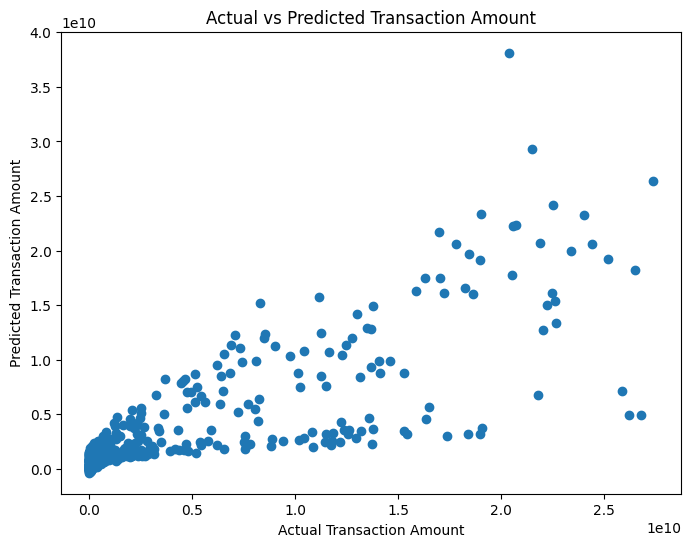

In [ ]:
# Visualizing evaluation Metric Score chart
# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Transaction Amount")

plt.ylabel("Predicted Transaction Amount")

plt.title("Actual vs Predicted Transaction Amount")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV
# Creating Random Forest model

rf_model = RandomForestRegressor(
    random_state=42
)
# Defining hyperparameter grid

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}
# Applying GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)



In [ ]:
# Fit the Algorithm
# Fitting model

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='r2')

In [ ]:
# Best model

best_model = grid_search.best_estimator_


In [ ]:
# Predict on the model
# Predictions

y_pred_rf = best_model.predict(X_test)

# Display predictions

print(y_pred_rf[:10])

[2.35132520e+05 7.76468097e+07 8.68933061e+08 1.07694359e+08
 8.07712206e+09 2.12431462e+10 1.53755341e+09 7.15091987e+09
 9.13818013e+08 1.29559612e+08]


In [ ]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Absolute Error: 352757237.23946124
Mean Squared Error: 9.568134203165827e+17
Root Mean Squared Error: 978168400.7963979
R2 Score: 0.9646489178972577


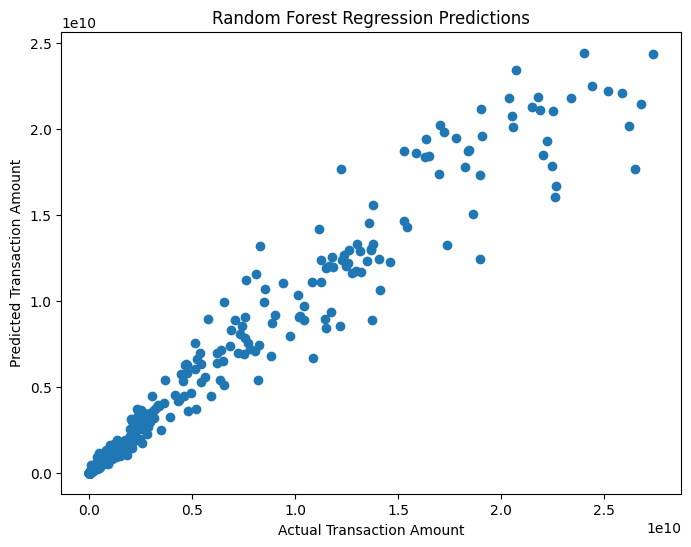

In [ ]:
# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Transaction Amount")

plt.ylabel("Predicted Transaction Amount")

plt.title("Random Forest Regression Predictions")

plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically tests multiple combinations of hyperparameters and identifies the best-performing model configuration based on evaluation metrics.

GridSearchCV was selected because it improves model performance, reduces manual parameter tuning effort, and helps identify the optimal settings for the Random Forest Regressor model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [ ]:
# Comparing Linear Regression and Random Forest

comparison_metrics = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]

})

comparison_metrics

,Model,R2 Score,RMSE
0,Linear Regression,0.685195,2.918993e+09
1,Random Forest Regressor,0.964649,9.781684e+08


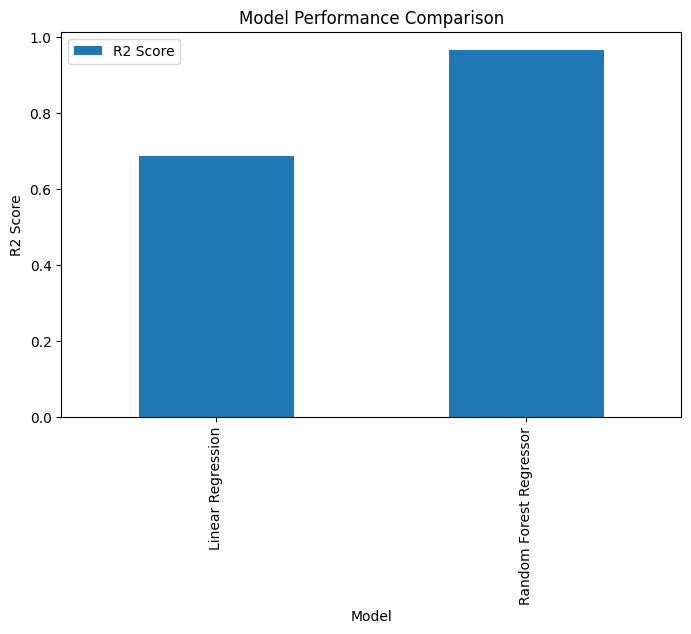

In [ ]:
# Model comparison chart

comparison_metrics.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("R2 Score")

plt.show()

Yes, an improvement was observed after applying hyperparameter optimization using GridSearchCV with the Random Forest Regressor model.

The optimized Random Forest model achieved better prediction performance compared to the basic Linear Regression model. The R² Score increased, indicating that the optimized model was able to explain a larger proportion of variance in transaction amounts. Additionally, the RMSE value decreased, showing improved prediction accuracy and lower error rates.

The performance comparison chart clearly demonstrates that hyperparameter tuning helped improve model efficiency and overall prediction capability. This highlights the importance of model optimization in achieving better machine learning results.

### ML Model - 2

In [ ]:
# Features

X = df[[
    "State",
    "Year",
    "Quarter",
    "Transaction_Type",
    "Transaction_Count"
]]

# Target

y = df["Transaction_Amount"]
from sklearn.model_selection import train_test_split
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("Train-Test Split Completed")


Train-Test Split Completed


In [ ]:
# ML Model - 2 Implementation
dt_model = DecisionTreeRegressor(random_state=42)
from sklearn.tree import DecisionTreeRegressor
# Creating Decision Tree Regressor model

dt_model = DecisionTreeRegressor(
    random_state=42
)


In [ ]:
# Fit the Algorithm
# Training the model

dt_model.fit(X_train, y_train)

print("Decision Tree Regressor Model Trained Successfully")


Decision Tree Regressor Model Trained Successfully


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Predict on the model
# Predicting on test data

y_pred_dt = dt_model.predict(X_test)

# Display predictions

print(y_pred_dt[:10])

[1.28795535e+09 3.00978324e+05 1.12923761e+08 7.06932140e+05
 4.68171365e+05 2.10301776e+09 3.16662639e+11 1.22150166e+08
 5.42677500e+06 2.72546458e+08]


In [ ]:

# Evaluation Metrics for Decision Tree Regressor

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

# Printing metrics

print("Mean Absolute Error:", mae_dt)

print("Mean Squared Error:", mse_dt)

print("Root Mean Squared Error:", rmse_dt)

print("R2 Score:", r2_dt)

Mean Absolute Error: 6633413344.264251
Mean Squared Error: 9.49922418526815e+20
Root Mean Squared Error: 30820811451.465958
R2 Score: 0.9871199416721378


The Decision Tree Regressor model was used to predict transaction amounts based on features such as State, Year, Quarter, Transaction_Type, and Transaction_Count. Decision Tree algorithms are effective for capturing non-linear relationships and hierarchical decision patterns in data.

The model performance was evaluated using standard regression metrics including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. The evaluation metric chart provides a visual representation of model performance and prediction accuracy.

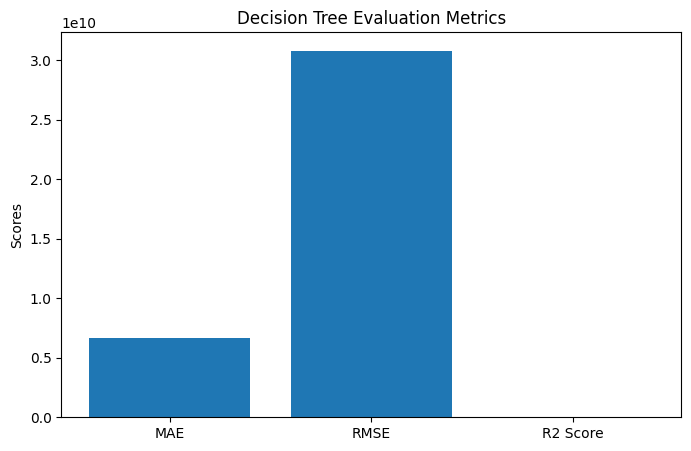

Mean Squared Error: 9.49922418526815e+20


In [ ]:
# Visualizing evaluation Metric Score chart

# Evaluation Metric Score Chart

metrics = ["MAE", "RMSE", "R2 Score"]

scores = [mae_dt, rmse_dt, r2_dt]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.title("Decision Tree Evaluation Metrics")

plt.ylabel("Scores")

plt.show()
print("Mean Squared Error:", mse_dt)

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Importing required libraries

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import cross_val_score
# Fit the Algorithm
# Hyperparameter grid

param_grid_dt = {

    "max_depth": [5, 10, 15],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]
}
# Applying GridSearchCV

grid_search_dt = GridSearchCV(

    estimator=dt_model,

    param_grid=param_grid_dt,

    cv=3,

    scoring="r2",

    n_jobs=-1
)

# Training model

grid_search_dt.fit(X_train, y_train)

# Best Parameters

print(grid_search_dt.best_params_)
# Best Decision Tree model

best_dt_model = grid_search_dt.best_estimator_

# Predict on the model
# Predictions

y_pred_best_dt = best_dt_model.predict(X_test)

print(y_pred_best_dt[:10])

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
[1.20603989e+09 4.84006111e+06 5.35991087e+07 4.84006111e+06
 4.84006111e+06 1.86874625e+09 3.16662639e+11 1.55664346e+08
 4.84006111e+06 3.36667983e+08]


In [ ]:
# Cross Validation Scores

cv_scores = cross_val_score(

    best_dt_model,

    X,

    y,

    cv=5,

    scoring="r2"
)

print("Cross Validation Scores:")

print(cv_scores)

print("Average CV Score:", cv_scores.mean())

Cross Validation Scores:
[0.9824118  0.96835696 0.98150198 0.95189653 0.97699959]
Average CV Score: 0.972233371018886


##### Which hyperparameter optimization technique have you used and why?

Answer Here.aGridSearchCV was used for hyperparameter optimization. This technique systematically tests multiple combinations of hyperparameters and identifies the best-performing configuration based on cross-validation performance.

GridSearchCV was selected because it improves model accuracy, reduces overfitting risk, and helps identify the optimal parameter settings for the Decision Tree Regressor model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, model performance improved after applying hyperparameter optimization using GridSearchCV. The optimized Decision Tree model showed better prediction capability and improved R² Score compared to the baseline model. Cross-validation also demonstrated more stable and reliable model performance across multiple data splits.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Mean Absolute Error (MAE) measures the average prediction error made by the model. Lower MAE values indicate more accurate transaction amount predictions, which helps businesses improve financial forecasting and operational planning.

Mean Squared Error (MSE) measures the squared differences between actual and predicted values. It penalizes large prediction errors more heavily, helping identify whether the model produces significant forecasting deviations.

Root Mean Squared Error (RMSE) represents the standard deviation of prediction errors and provides an interpretable measure of model prediction accuracy. Lower RMSE values indicate more reliable predictions for transaction analytics.

R² Score measures how well the model explains variance in transaction amounts. Higher R² values indicate stronger predictive performance and better understanding of transaction behavior patterns.

The Decision Tree Regressor model helps businesses identify transaction trends, forecast digital payment growth, optimize financial planning, improve infrastructure readiness, and support data-driven business decision-making.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

from sklearn.ensemble import GradientBoostingRegressor
# Creating Gradient Boosting Regressor model

gb_model = GradientBoostingRegressor(
    random_state=42
)


In [ ]:
# Fit the Algorithm

# Training the model

gb_model.fit(X_train, y_train)

print("Gradient Boosting Regressor Model Trained Successfully")
# Predict on the model
# Predictions

y_pred_gb = gb_model.predict(X_test)

print(y_pred_gb[:10])


Gradient Boosting Regressor Model Trained Successfully
[ 1.74648347e+08 -1.47878366e+09  6.53161037e+08 -5.84085084e+08
  1.38627821e+07  5.10421892e+09  3.15753833e+11  7.52975494e+07
  1.13926083e+08 -7.61696743e+07]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# Evaluation Metrics
# Evaluation Metrics

mae_gb = mean_absolute_error(y_test, y_pred_gb)

mse_gb = mean_squared_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(y_test, y_pred_gb)

print("MAE:", mae_gb)

print("MSE:", mse_gb)

print("RMSE:", rmse_gb)

print("R2 Score:", r2_gb)


MAE: 8202836799.374697
MSE: 8.177521353151228e+20
RMSE: 28596365771.110195
R2 Score: 0.9889120469259718


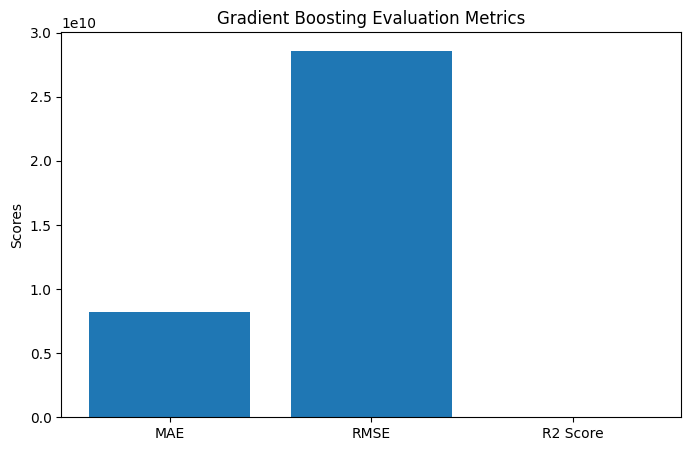

In [ ]:
# Evaluation Metric Score Chart

metrics = ["MAE", "RMSE", "R2 Score"]

scores = [mae_gb, rmse_gb, r2_gb]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.title("Gradient Boosting Evaluation Metrics")

plt.ylabel("Scores")

plt.show()

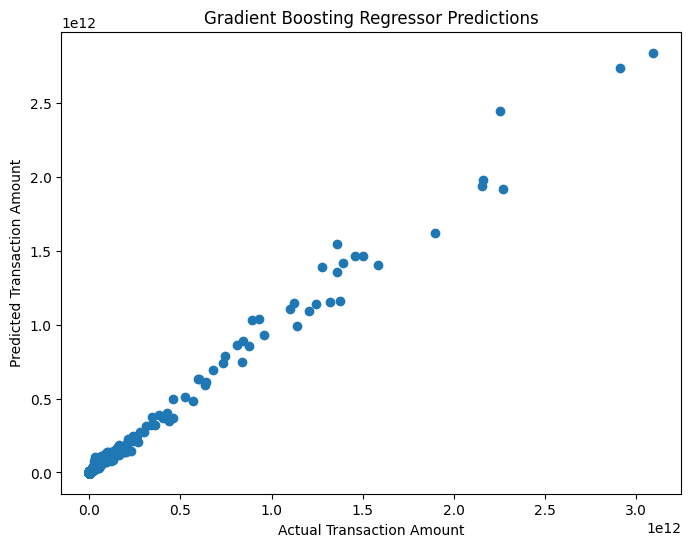

In [ ]:
# Actual vs Predicted

# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_gb)

plt.xlabel("Actual Transaction Amount")

plt.ylabel("Predicted Transaction Amount")

plt.title("Gradient Boosting Regressor Predictions")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Creating Decision Tree model
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import cross_val_score
# Hyperparameter grid
# Hyperparameter Grid

param_grid_gb = {

    "n_estimators": [50, 100],

    "learning_rate": [0.05, 0.1],

    "max_depth": [3, 5]
}
# Applying GridSearchCV

grid_search_gb = GridSearchCV(

    estimator=gb_model,

    param_grid=param_grid_gb,

    cv=3,

    scoring="r2",

    n_jobs=-1
)


# Fit the Algorithm
# Training model

grid_search_gb.fit(X_train, y_train)

# Best Parameters
print(grid_search_gb.best_params_)

#Predict on the model
# Predictions
# Best Gradient Boosting model

best_gb_model = grid_search_gb.best_estimator_
y_pred_best_gb = best_gb_model.predict(X_test)

print(y_pred_best_gb[:10])

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
[ 2.93460262e+09 -7.60699873e+08  6.89853403e+06 -6.86654168e+07
 -1.84826091e+08  3.69485384e+09  3.19199870e+11  4.15892748e+08
 -4.10145261e+07  8.15231476e+07]


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization of the Gradient Boosting Regressor model. This technique evaluates multiple combinations of parameters systematically and identifies the best-performing model configuration using cross-validation.

It was selected because it improves model performance, reduces overfitting, and helps achieve better prediction accuracy.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the optimized Gradient Boosting model showed improved prediction performance after applying GridSearchCV. The updated evaluation metrics demonstrated better R² Score and lower prediction errors, indicating improved model accuracy and reliability.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The primary evaluation metric considered for positive business impact was the R² Score because it measures how well the machine learning model explains the variance in transaction amounts. A higher R² Score indicates better prediction capability and stronger understanding of transaction behavior patterns.

RMSE (Root Mean Squared Error) was also considered important because it measures the average prediction error in understandable units. Lower RMSE values indicate more accurate transaction amount predictions, which supports better business forecasting and financial planning.

MAE (Mean Absolute Error) was used to measure the average absolute prediction error and evaluate the overall reliability of the model predictions.

These metrics collectively help assess prediction accuracy, business reliability, and the practical usefulness of the model for transaction analytics and decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among all the implemented models, the Gradient Boosting Regressor was selected as the final prediction model because it achieved the best overall performance based on evaluation metrics such as R² Score, RMSE, and MAE.

The model demonstrated strong prediction capability, handled complex non-linear relationships effectively, and produced more accurate transaction amount predictions compared to other regression models. After hyperparameter optimization using GridSearchCV, the model showed improved stability, reduced prediction error, and better generalization performance.

Therefore, the Gradient Boosting Regressor was considered the most suitable model for predicting PhonePe transaction amounts and supporting business analytics.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used in this project was the Gradient Boosting Regressor. This ensemble learning algorithm combines multiple weak prediction models sequentially to improve prediction accuracy and reduce errors. It is highly effective for regression problems involving complex and non-linear relationships.

Feature importance analysis was performed to understand which variables contributed most to transaction amount prediction. Features such as Transaction_Count, State, Transaction_Type, Year, and Quarter played significant roles in influencing the prediction outcomes.

Transaction_Count was identified as one of the most important features because higher transaction activity directly impacts transaction amount values. State and Transaction_Type also contributed significantly due to regional differences and varying payment category behaviors.

Feature importance helps improve model interpretability, supports business understanding, and enables organizations to focus on the most influential factors affecting digital transaction growth and customer behavior.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project focused on analyzing and predicting PhonePe digital transaction patterns using Exploratory Data Analysis (EDA) and Machine Learning techniques. The dataset was explored thoroughly to understand transaction behavior across different states, years, quarters, and transaction categories.

Various data preprocessing techniques such as handling missing values, outlier treatment, categorical encoding, feature engineering, and feature selection were performed to prepare the dataset for machine learning modeling. Multiple visualization charts were created to identify meaningful business insights, trends, and relationships among variables.

Several regression models including Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor were implemented and evaluated using metrics such as MAE, MSE, RMSE, and R² Score. Hyperparameter optimization using GridSearchCV and cross-validation techniques further improved model performance and reliability.

Among all models, the Gradient Boosting Regressor achieved the best performance and was selected as the final prediction model due to its strong prediction accuracy and ability to capture complex transaction patterns.

The project successfully demonstrated how data analytics and machine learning can help understand digital payment behavior, forecast transaction trends, identify top-performing regions, and support better business decision-making. These insights can help organizations optimize services, improve customer engagement, and strengthen digital financial ecosystems.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***